In [1]:
# Configure logging for verbose solver output
import logging
import json
import numpy as np
import scipy.constants as const

def setup_logging(level=logging.INFO):
    fmt = "[%(levelname)s] %(name)s: %(message)s"
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter(fmt))

    for name in ("membrane_reactor", "solvers"):
        lg = logging.getLogger(name)
        # Avoid duplicate handlers in notebooks
        lg.handlers = []
        lg.addHandler(handler)
        lg.propagate = False
        lg.setLevel(level)

    # Root logger for any fallbacks
    root = logging.getLogger()
    root.setLevel(level)

# Set INFO for high-level progress; use DEBUG for per-iteration details
setup_logging(logging.INFO)

def calculate_flows(GHSV, eps, Dcat, rho_c, L_membrane, Lsealing, r_max, r_min, Nm, sweep_ratio, H2_N2_ratio, T_STP = 273.15, P_STP = 101325.0):

    # 1. Parameter calculation for reactor design
    L_bed = L_membrane + Lsealing      #catalyst bed
    A_reactor = np.pi * (r_max**2 - r_min**2 * Nm)
    A_membrane = 2 * np.pi * r_min * L_membrane * Nm   # to be used when the permeating flux wants to be calculate from the permeance
    vol_reactor = A_reactor * L_bed 
    vol_cat = Dcat * (1 - eps) * vol_reactor
    W_cat = vol_cat * rho_c
    
    #Membrane Area/reactor volume parameter
    S_over_V = 2 * (r_min *Nm) /(r_max**2 - Nm * r_min**2)
    
    """
    Converts GHSV (1/h) and Geometry to F_ret_in and F_perm_in (mol/s).
    Includes H2:N2 ratio logic.
    """   
    # 2. Volumetric Flow at STP (Standard T=273.15K, P=101325 Pa)
    vol_flow_std = (GHSV * vol_cat) / 3600.0

    WHSV = vol_flow_std / W_cat    #another way to express the gas space velocity

    # 3. Total Molar Flow (Ideal Gas Law at STP)
    F_ret_in = (P_STP * vol_flow_std) / (const.R * T_STP)
    
    # 4. Species Mole Fractions based on H2:N2 Ratio
    # Ratio R = H2/N2 -> H2 = R*N2 -> x_H2 + x_N2 = 1 (assuming pure feed for simplicity)
    # x_N2 * (R + 1) = 1  => x_N2 = 1 / (R + 1)
    y_N2_in = 1.0 / (H2_N2_ratio + 1.0)
    y_H2_in = 1.0 - y_N2_in
    
    # Note: If your defaults.py requires specific species fractions, 
    # you might need to adjust DEFAULTS['x_ret_in'] separately.
    
    # 5. Calculate Permeate Flow
    F_perm_in = F_ret_in * sweep_ratio

    # 6. Dimensionless number
    #Re_ret = rho_ret * self.dp * np.abs(u_ret_i) / visc_ret
    #Pr_ret = visc_ret * cp_ret / lmbda_ret_rad[:,[0]]
    #Re_perm = rho_perm * d_tube * np.abs(u_perm_i) / visc_perm
    #Pr_perm = visc_perm * cp_perm / lmbda_perm_rad[:,[-1]]
    #Sc_ret = viscosity / rho_g / np.mean(D)
    #Pe_ret = Re_ret * Sc_ret
    #Da_local = rate / flows_ret_ax
    #Da_z = np.mean(Da_local, axis=0)  # axial avg

    # Shwerwood correlation to be fitted
    #calculate mass t
    # ransfer coefficient (k) from flux at membrane interface and concentration

    
    return F_ret_in, F_perm_in, y_H2_in, y_N2_in, W_cat, WHSV, S_over_V, vol_reactor, A_membrane, A_reactor

class SafeEncoder(json.JSONEncoder):
    def default(self, obj):
        # 1. Handle NumPy generic integers/floats
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        
        # 2. Handle NumPy Arrays
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        
        # 3. Handle Functions and Lambdas (The fix for your issue)
        #elif isinstance(obj, (types.FunctionType, types.LambdaType)) or callable(obj):
            # Return the string representation (e.g. "<function <lambda> at ...>")
            # or you can return "Skipped Function" if you prefer
        #    return str(obj)
        
        # 4. Fallback for other non-serializable objects
        return super().default(obj)

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os
import scipy.constants as const

from defaults import DEFAULTS
import membrane_reactor
import importlib
importlib.reload(membrane_reactor)
from membrane_reactor import MembraneReactor

F_SMALL = 1e-14

csv_path = "case_studies_singlemem.csv"
# 1. Load the CSV
df = pd.read_csv(csv_path)

results = []

# 2. Loop over only the first case
for index, row in df.loc[[1]].iterrows():
    case_id = row['Case_ID']
    print(f"\n=== Running Case: {case_id} ({row['Description']}) ===")
    
    # Create Output Directory
    out_dir = os.path.join("results", case_id)
    os.makedirs(out_dir, exist_ok=True)
    
    # -- Geometry -- (CSV file)
    r_min = DEFAULTS['r_min']
    r_max = row['r_max_m']
    Nm = row ['N_mem']   #added
    L_membrane = row ['L_m']   #added
    Lsealing = DEFAULTS['Lsealing']    #added
    Dcat = row ['Dcat']   #added
    
    # -- Bed / catalyst properties from DEFAULTS --
    eps = DEFAULTS['eps']    #added
    rho_c = DEFAULTS['rho_c']    #added

    # -- Flows & Composition --
    GHSV = row['GHSV_h']
    sweep_ratio = row['Sweep_Ratio']
    H2_N2_ratio = row['H2_N2_ratio']

    F_ret_in, F_perm_in, y_H2_in, y_N2_in, W_cat, WHSV, S_over_V, vol_reactor, A_membrane, A_reactor  = calculate_flows( GHSV=GHSV,eps=eps, rho_c=rho_c, sweep_ratio=sweep_ratio, H2_N2_ratio=H2_N2_ratio,r_min=r_min, r_max=r_max, Nm=Nm,Lsealing=Lsealing, L_membrane=L_membrane, Dcat=Dcat )
    y_ret_in = np.array([y_H2_in, y_N2_in, 0.0])

    p_ret_out = row['p_ret_bar'] * 1e5
    p_perm = row ['p_perm_bar'] * 1e5  #added
    T_ret_in = row['T_ret_K']
    T_perm_in = row['T_perm_K']
    is_counter_current = row['Is_Counter_Current']
    Perm_NH3 = row['Perm_NH3']  #added

    # 4. Initialize and Solve
    try:
        reactor = MembraneReactor(
            L=L_membrane+Lsealing,
            r_min=r_min,
            r_max=r_max,
            p_ret_out=p_ret_out,
            T_ret_in=T_ret_in,
            T_perm_in=T_perm_in,
            F_ret_in=F_ret_in,
            F_perm_in=F_perm_in,
            y_ret_in=y_ret_in,
            is_counter_current=is_counter_current,
            Perm_NH3=Perm_NH3,
            factor_react=1.0,
            factor_p = 1e0,
            num_r=4,
            num_z=10,
            num_timesteps=100,
            num_newton_iterations=1,  # Maximum number of outer iterations
            num_concentration_iterations=100,
            is_isothermal=True
        )
        reactor.solve(verbose=2, dt_init=1e0)
        #reactor.solve(verbose=2)
        # 5. Save Raw Data
        # Save configuration for reproducibility
        with open(os.path.join(out_dir, "config.json"), 'w') as f:
            # Filter out non-serializable items (like numpy arrays) if necessary
            json.dump(reactor.param_dict, f, indent=4, cls=SafeEncoder)
        
        flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

        #OUTPUTS
        #compute key performance indicators
        F_H2_ret_z = flows_ret_ax[:, 0]
        F_H2_perm_z = flows_perm_ax[:, 0]

        F_NH3_ret_z = flows_ret_ax[:, 2]
        F_NH3_perm_z = flows_perm_ax[:, 2]

        F_H2_in_ret = F_H2_ret_z[0]
        F_H2_in_perm = F_H2_perm_z[0]
        F_H2_in_tot  = F_H2_in_ret + F_H2_in_perm

        # net H2 that has gone into permeate up to each z
        F_H2_tm = F_H2_perm_z - F_H2_perm_z[0]       # array

        # only count segments where net flow is from retentate to permeate
        F_H2_tm_star = np.where(F_H2_tm <= 0.0, F_H2_tm, 0.0)
        
        F_H2_out = flows_ret_ax[-1, 0]         # H2 out at retentate outlet
        F_NH3_in = flows_ret_ax[0, 2]        # NH3 at outlet
        F_NH3_out = flows_ret_ax[-1, 2]        # NH3 at outlet

        # H2 conversion (array vs z)
        X_H2 = (F_H2_in_ret - F_H2_ret_z - F_H2_tm) / (F_H2_in_ret - F_H2_tm_star)

        # NH3 productivity (mol/Kgcat/s) at outlet
        NH3_prod = F_NH3_out/W_cat

        # NH3 recovery in permeate (array vs z)
        NH3_rec = F_NH3_perm_z / (F_SMALL + F_NH3_perm_z + F_NH3_ret_z)

        # NH3 yield based on total fed H2
        NH3_yield = 3 *(F_NH3_perm_z + F_NH3_ret_z) / ( 2 * F_H2_in_tot)

        # Example: average H2 flux at membrane
        #J_H2 = flows_ret_mem[0] / A_membrane 
        J_H2_avg = flows_ret_mem[0] / A_membrane

        # Example: maximum temperature rise
        DeltaT_max = float(np.max(reactor.cpT[..., -1] - reactor.T_ret_in))

        # ---- KPIs as scalars for the table ----

        # H2 conversion: take outlet value (last z)
        X_H2_out = float(X_H2[-1])

        # NH3 productivity at outlet (already scalar)
        NH3_prod_out = float(NH3_prod)

        # NH3 recovery in permeate: outlet value
        NH3_rec_out = float(NH3_rec[-1])

        # NH3 yield based on total fed H2: outlet value
        NH3_yield_out = float(NH3_yield[-1])

        # already scalar:
        J_H2_avg = float(J_H2_avg)
        DeltaT_max = float(DeltaT_max)

        results.append(dict(
        # INPUTS (to identify the case)
        Case_ID = case_id,
        Description = row["Description"],
        GHSV_h = GHSV,
        Nm = Nm,
        L_m = L_membrane,
        Dcat = Dcat,
        p_ret_bar = row["p_ret_bar"],
        p_perm_bar = row["p_perm_bar"],
        T_ret_K = T_ret_in,
        T_perm_K = T_perm_in,
        Sweep_Ratio = sweep_ratio,
        H2_N2_ratio = H2_N2_ratio,
        WHSV = WHSV,
        S_over_V = S_over_V,
        vol_reactor_m3 = vol_reactor,
        A_membrane_m2 = A_membrane,
        A_reactor_m2 = A_reactor,
        r_max = r_max,

        # OUTPUTS (KPIs)
        X_H2_out=X_H2_out,
        NH3_prod_out=NH3_prod_out,
        NH3_rec_out=NH3_rec_out,
        NH3_yield_out=NH3_yield_out,
        J_H2_avg=J_H2_avg,
        DeltaT_max=DeltaT_max
        ))
        

        print(f'axial flows retentate side: left {flows_ret_ax[0,:]} right {flows_ret_ax[-1,:]}')
        print(f'axial flows permeate side: left {flows_perm_ax[0,:]} right {flows_perm_ax[-1,:]}')
        flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
        print(f'total balance per component: {flows_tot}')
        print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
        print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

    except Exception as e:
        print(f"Case {case_id} failed: {e}")

    if results:
       df_out = pd.DataFrame(results)
       os.makedirs("results", exist_ok=True)
       out_csv = os.path.join("results", "summary_results.csv")
       df_out.to_csv(out_csv, index=False)
       print(f"\nSaved summary results to: {out_csv}")
    else:
       print("No successful cases, no summary file written.")




=== Running Case: N1_GHSV_1000 (Single membrane, GHSV=1000) ===
Starting adaptive dt solve: dt_init=1.00e+00, dt_range=[1.00e-06, 1.00e+07]
  Step 0: dt=1.00e+00, ||g_ss||=8.26e+00
  Step 1: poor (red=1.16), dt -> 5.00e-01, ||g_ss||=9.55e+00
  Step 2: ok (red=0.97), dt -> 1.00e+00, ||g_ss||=9.30e+00
  Step 3: ok (red=0.95), dt -> 2.00e+00, ||g_ss||=8.84e+00
  Step 4: ok (red=0.91), dt -> 4.00e+00, ||g_ss||=8.00e+00
  Step 5: ok (red=0.83), dt -> 8.00e+00, ||g_ss||=6.65e+00
  Step 6: ok (red=0.72), dt -> 1.60e+01, ||g_ss||=4.79e+00
  Step 7: ok (red=0.60), dt -> 3.20e+01, ||g_ss||=2.86e+00
  Step 8: ok (red=0.53), dt -> 6.40e+01, ||g_ss||=1.51e+00
  Step 9: ok (red=0.59), dt -> 1.28e+02, ||g_ss||=8.87e-01
  Step 10: good (red=0.45), dt -> 5.12e+02, ||g_ss||=3.98e-01
  Step 11: good (red=0.12), dt -> 2.05e+03, ||g_ss||=4.72e-02
  Step 12: good (red=0.03), dt -> 8.19e+03, ||g_ss||=1.53e-03
  Step 13: ok (red=0.66), dt -> 1.64e+04, ||g_ss||=1.01e-03
  Step 14: ok (red=0.92), dt -> 3.28e+0

In [11]:
reactor.u_ret_ax[-1,:]

array([0.00038417, 0.0003848 ])

[INFO] membrane_reactor: Residence time retentate side: 389.4387 s
[INFO] membrane_reactor: Residence time permeate side: 0.1090 s


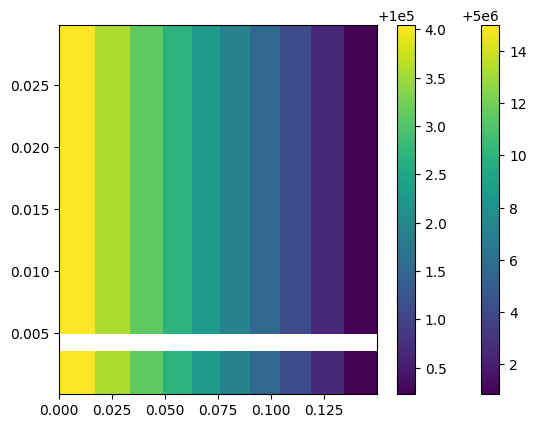

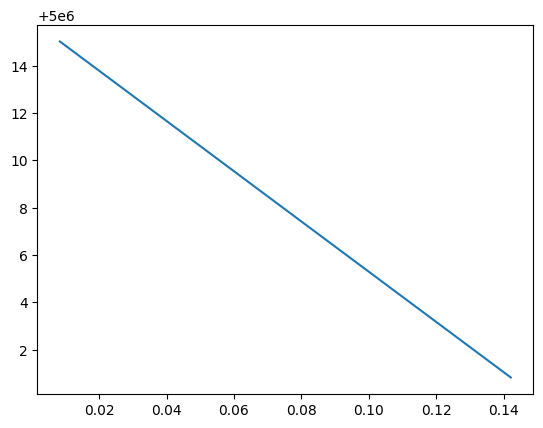

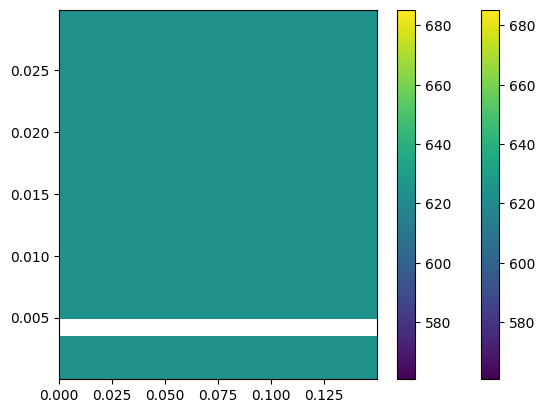

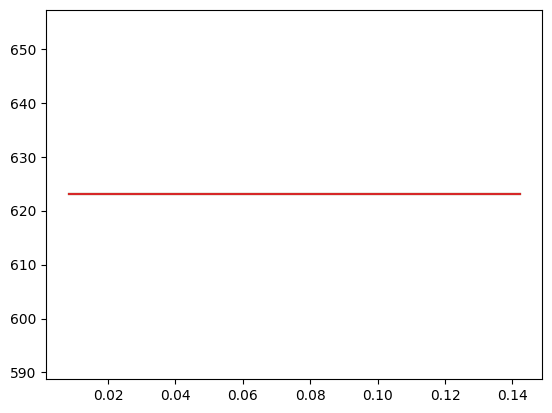

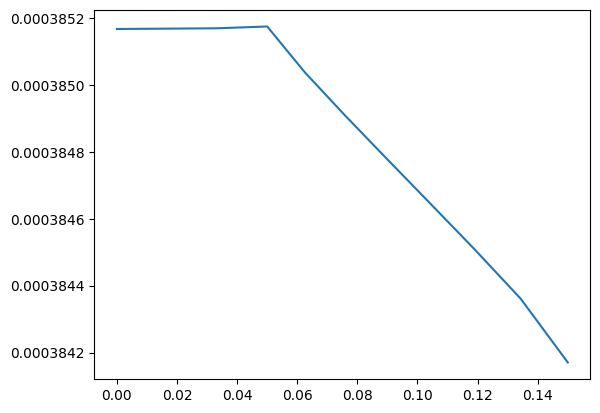

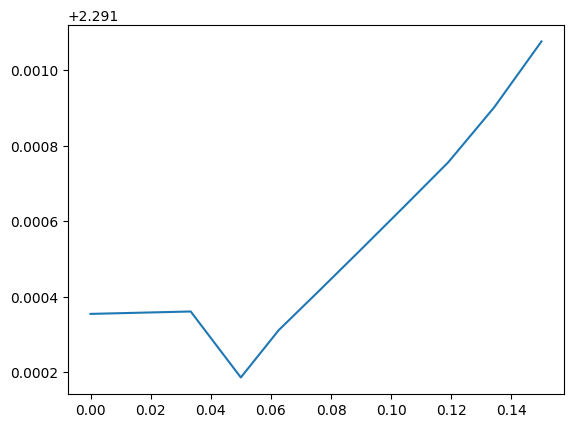

axial flows retentate side: [[6.81344325e-04 3.40672162e-04 0.00000000e+00]
 [6.79881063e-04 3.40637569e-04 2.94205181e-77]]
axial flows permeate side: [[ 0.00000000e+00  1.02201649e-03  0.00000000e+00]
 [ 1.46326238e-06  1.02205108e-03 -2.10359350e-79]]
total balance per component: [-9.03812797e-13 -4.70741501e-13 -2.92101587e-77]
elemental H balance: -1.8076255947024162e-12
elemental N balance: -9.414830026699406e-13
membrane flow retentate side: [-1.46326238e-06 -3.45935940e-08  2.10145495e-79]
membrane flow permeate side: [-1.46326238e-06 -3.45935940e-08  2.10145495e-79]


In [12]:
reactor.info()
    
p = reactor.cpT[...,-2]
p_vect = p.ravel()
p_perm = p[:, :reactor.num_r_perm]
p_ret = p[:, reactor.num_r_perm:]
p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, p_perm[:, :].T)
plt.colorbar()
plt.show()

# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, reactor.div_u[:, reactor.num_r_perm:].T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, reactor.div_u[:, :reactor.num_r_perm].T)
# plt.colorbar()
# plt.show()

# T_perm = reactor.T[:, :reactor.num_r_perm]
# T_ret = reactor.T[:, reactor.num_r_perm:]
# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, T_ret[:, :].T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, T_perm[:, :].T)
# plt.colorbar()
# plt.show()

#k_f = reactor.kinetics.k_f
#plt.pcolormesh(reactor.z_c, reactor.r_c_ret, k_f.T)
#plt.colorbar()
#plt.show()

# c_perm = reactor.c_p[:, :reactor.num_r_perm,:-1]
# c_ret = reactor.c_p[:, reactor.num_r_perm:,:-1]
# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, c_ret[:, :, 0].T)
# plt.colorbar()
# plt.show()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, c_perm[:, :, 0].T)
# plt.colorbar()
# plt.show()

# plt.pcolormesh(reactor.z_f, reactor.r_c_ret, reactor.u_ret_ax.T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_f, reactor.r_c_perm, reactor.u_perm_ax.T)
# plt.colorbar()
# plt.show()
# plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0], '.')
# plt.plot(reactor.z_f, reactor.u_ret_ax[:, -1], '.')
# plt.show()
#plt.plot(reactor.z_c, reactor.c_p[:, 0,-1], '-')
plt.plot(reactor.z_c, reactor.cpT[:, -1,-2])
#plt.plot(reactor.z_c, reactor.c_p[:, -2,-1])
#plt.plot(reactor.z_c, reactor.c_p[:, -3,-1])
#plt.plot(reactor.z_c, np.sum(reactor.c_p[:, 0,:-1],axis=-1)*8.314*reactor.T[:,0], 'o')
plt.show()
#plt.plot(reactor.z_c, reactor.c_p[:, 0,-1])
#plt.show()

T = reactor.cpT[..., -1]
T_vect = T.ravel()
T_perm = T[:, :reactor.num_r_perm]
T_ret = T[:, reactor.num_r_perm:]
T_min = np.min(T)
T_max = np.max(T)
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, T_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, T_perm[:, :].T)
plt.colorbar()
plt.show()

plt.plot(reactor.z_c,T_perm[:, 0])
plt.plot(reactor.z_c, T_perm[:, 1])
plt.plot(reactor.z_c,T_ret[:, 0])
plt.plot(reactor.z_c, T_ret[:, 1])
plt.show()

plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0], '-')
plt.show()
plt.plot(reactor.z_f, reactor.u_perm_ax[:, 0], '-')
plt.show()


flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

print(f'axial flows retentate side: {flows_ret_ax[[0,-1],...]}')
print(f'axial flows permeate side: {flows_perm_ax[[0,-1],...]}')
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

print(f'membrane flow retentate side: {flows_ret_mem}')
print(f'membrane flow permeate side: {flows_perm_mem}')


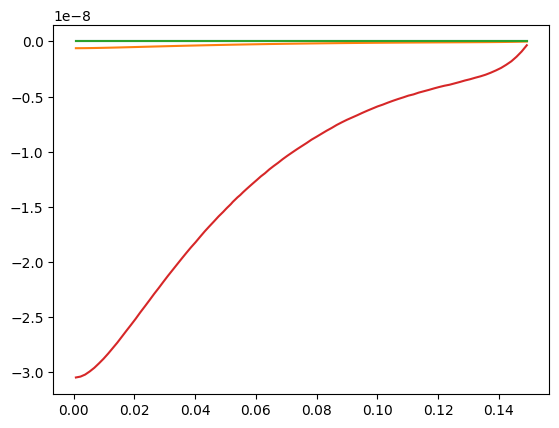

In [8]:
plt.plot(reactor.z_c, reactor.u_ret_rad[:, 0])
plt.plot(reactor.z_c, reactor.u_ret_rad[:, 1])
#plt.plot(reactor.z_c, reactor.u_ret_rad[:, 2])
#plt.plot(reactor.z_c, reactor.u_ret_rad[:, 3])
plt.plot(reactor.z_c, reactor.u_ret_rad[:, -1]*50)
plt.plot(reactor.z_c, reactor.u_ret_rad[:, -2]*50)



plt.show()

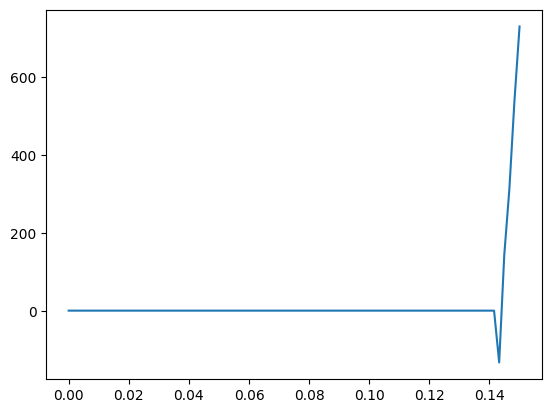

In [6]:
fl_diff_ret_ax, fl_diff_ret_rad, fl_diff_perm_ax, fl_diff_perm_rad = reactor._compute_fluxes_diff()
fl_conv_ret_ax, fl_conv_ret_rad, fl_conv_perm_ax, fl_conv_perm_rad = reactor._compute_fluxes_conv()

flux_matrix_ret_mem = reactor.flux_matrix_ret_mem
flux_matrix_perm_mem = reactor.flux_matrix_perm_mem

flux_ret_mem = (flux_matrix_ret_mem @ reactor.c_p[..., :-1].reshape((-1, 1))).reshape(fl_diff_ret_rad.shape)
flux_perm_mem = (flux_matrix_perm_mem @ reactor.c_p[..., :-1].reshape((-1, 1))).reshape(fl_diff_perm_rad.shape)

#plt.plot(reactor.z_c, fl_diff_ret_rad[:, 1, 1]+fl_conv_ret_rad[:, 1, 1])
plt.plot(reactor.z_f, fl_diff_ret_ax[:, 0, 1]+fl_conv_ret_ax[:, 0, 1])
#plt.plot(reactor.z_c, fl_diff_ret_rad[:, 1, 1])
#plt.plot(reactor.z_c, fl_diff_ret_rad[:, 0, 1]+fl_conv_ret_rad[:, 0, 1])
#plt.plot(reactor.z_c, flux_ret_mem[:, 0, 1],'o')
#plt.plot(reactor.z_c, flux_perm_mem[:, -1, 1],'o')
#plt.plot(reactor.z_c, fl_diff_perm_rad[:, -1, 1]+fl_conv_perm_rad[:, -1, 1])
#plt.plot(reactor.z_c, fl_diff_perm_rad[:, -2, 1]+fl_conv_perm_rad[:, -2, 1])
plt.show()



In [10]:
fl_conv_ret_ax, fl_conv_ret_rad, fl_conv_perm_ax, fl_conv_perm_rad = reactor.compute_fl_conv_conv()

plt.plot(reactor.z_f, fl_conv_ret_ax[:, -1, 2])
plt.plot(reactor.z_f, fl_conv_ret_ax[:, 0, 2])
plt.show()

plt.plot(reactor.z_f, reactor.u_ret_ax[:, -1])
plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0])
plt.show()


AttributeError: 'MembraneReactor' has no attribute 'compute_fl_conv_conv'

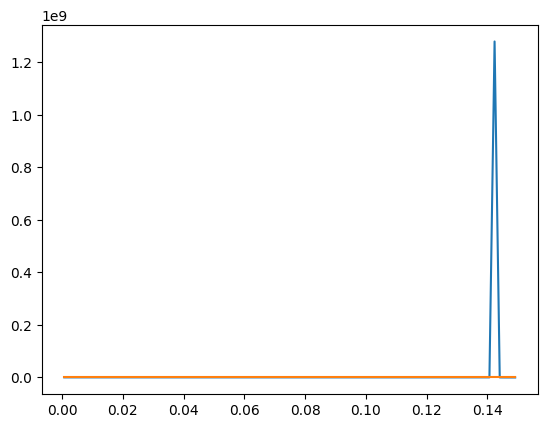

In [8]:
plt.plot(reactor.z_c, reactor.c_p[:, reactor.num_r_perm,0])
plt.plot(reactor.z_c, np.sum(reactor.c_p[:, reactor.num_r_perm-1,:], axis = -1))
plt.show()

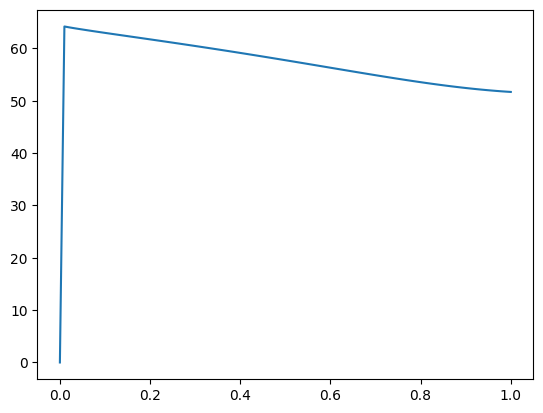

In [ ]:
plt.plot(reactor.z_f, np.sum(np.array([[0,2,-1]])*reactor.c_ret_ax[:,-1,:], axis=-1)*reactor.u_ret_ax[:,-1])

In [ ]:
from scipy import constants
c_tot = np.sum(membrane_reactor.c,axis=-1)
y = membrane_reactor.c / c_tot[..., np.newaxis]
c_tot_p = membrane_reactor.correlation.molar_density(y, membrane_reactor.T, membrane_reactor.p)

plt.plot(membrane_reactor.z_c, c_tot[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, c_tot_p[:, -1], '.-g')
plt.show()

#plt.plot(membrane_reactor.z_c, c_tot[:,0], 'o-r')
#plt.plot(membrane_reactor.z_c, c_tot_p[:,0], '.-g')
#plt.show()

p_ig = c_tot_p * constants.R * membrane_reactor.T
plt.plot(membrane_reactor.z_c, p_ig[:,-1], 'o-r')
plt.plot(membrane_reactor.z_c, membrane_reactor.p[:, -1], '.-g')
plt.show()


plt.plot(membrane_reactor.z_f, membrane_reactor.u_ret_ax[:,-1], '-')
plt.show()

grad_p = membrane_reactor.grad_p_ret_ax @ membrane_reactor.p.reshape((-1,1)) + membrane_reactor.grad_bc_p_ret_ax
grad_p = grad_p.reshape((membrane_reactor.num_z+1,-1))
plt.plot(membrane_reactor.z_f[1:], grad_p[1:,-1], '-')
plt.show()

AttributeError: module 'membrane_reactor' has no attribute 'c'